In [1]:
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langchain_core.messages import RemoveMessage,HumanMessage,BaseMessage
from langchain_groq import ChatGroq
from typing import TypedDict,Annotated,List
from dotenv import load_dotenv
import os
from langgraph.checkpoint.memory import InMemorySaver


e:\LangGraph\myenv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer
e:\LangGraph\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv(dotenv_path=".env", override=True)
GROQ_API_KEY = os.getenv('GROQ_API_KEY')
model = ChatGroq(
    model="llama-3.3-70b-versatile",  
    api_key=GROQ_API_KEY  
)

In [3]:
class chatstate(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]
    summary:str

In [4]:
def summarizer(state:chatstate):
    summary=state['summary']
    messages=state['messages']
    if summary:
        prompt = (
            f"Existing summary:\n{summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."
        messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]
    response=model.invoke(messages_for_summary)
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [5]:
def chat_node(state: chatstate):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [6]:
def should_summarize(state: chatstate):
    return len(state["messages"]) > 6

In [8]:
builder = StateGraph(chatstate)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarizer)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")

In [9]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

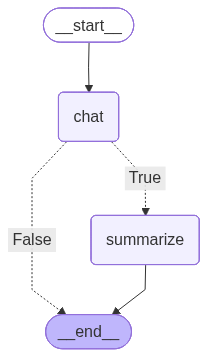

In [10]:
graph

In [11]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [12]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [13]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='f9741a46-41cd-4c7d-9b6a-398aee081c7c')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics, also known as quantum mechanics, is a branch of physics that st


In [14]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='f9741a46-41cd-4c7d-9b6a-398aee081c7c'), AIMessage(content='Quantum physics, also known as quantum mechanics, is a branch of physics that studies the behavior of matter and energy at the smallest scales. At these scales, the classical laws of physics do not apply, and strange, seemingly random phenomena govern the behavior of particles.\n\n**Key Principles of Quantum Physics:**\n\n1. **Wave-Particle Duality**: Quantum objects, such as electrons, can exhibit both wave-like and particle-like behavior depending on how they are observed.\n2. **Uncertainty Principle**: It is impossible to know certain properties of a quantum object, such as its position and momentum, simultaneously with infinite precision.\n3. **Superposition**: Quantum objects can exist in multiple states simultaneously, which is known as a superposition of states.\n4. **Entanglement**: Quantum objects can become "entangled" in such a w

In [15]:
run_turn('What are some of Einstien"s fampus work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='f9741a46-41cd-4c7d-9b6a-398aee081c7c'), AIMessage(content='Quantum physics, also known as quantum mechanics, is a branch of physics that studies the behavior of matter and energy at the smallest scales. At these scales, the classical laws of physics do not apply, and strange, seemingly random phenomena govern the behavior of particles.\n\n**Key Principles of Quantum Physics:**\n\n1. **Wave-Particle Duality**: Quantum objects, such as electrons, can exhibit both wave-like and particle-like behavior depending on how they are observed.\n2. **Uncertainty Principle**: It is impossible to know certain properties of a quantum object, such as its position and momentum, simultaneously with infinite precision.\n3. **Superposition**: Quantum objects can exist in multiple states simultaneously, which is known as a superposition of states.\n4. **Entanglement**: Quantum objects can become "entangled" in such a w

In [16]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='f9741a46-41cd-4c7d-9b6a-398aee081c7c'), AIMessage(content='Quantum physics, also known as quantum mechanics, is a branch of physics that studies the behavior of matter and energy at the smallest scales. At these scales, the classical laws of physics do not apply, and strange, seemingly random phenomena govern the behavior of particles.\n\n**Key Principles of Quantum Physics:**\n\n1. **Wave-Particle Duality**: Quantum objects, such as electrons, can exhibit both wave-like and particle-like behavior depending on how they are observed.\n2. **Uncertainty Principle**: It is impossible to know certain properties of a quantum object, such as its position and momentum, simultaneously with infinite precision.\n3. **Superposition**: Quantum objects can exist in multiple states simultaneously, which is known as a superposition of states.\n4. **Entanglement**: Quantum objects can become "entangled" in such a w